# 07. Interference and Network Effects

Most introductory causal inference assumes that one unit's treatment does not affect another unit's outcome. That assumption is convenient, and in many experiments it is approximately reasonable. But it is often wrong in industry.

A seller ranking boost can take attention away from other sellers. A driver incentive can change rider wait times for everyone nearby. A collaboration tool can help treated employees and also their teammates. A social feed change can alter what untreated friends see. A fraud rule can move bad actors to another part of the platform. A promotion can change market prices, inventory, congestion, or competition.

This is **interference**: unit $i$'s outcome may depend on unit $j$'s treatment.

The central idea of this notebook is:

> When interference is present, the estimand is not just "the treatment effect." We must define whose treatment, whose outcome, and what treatment environment.

The same experiment can estimate a direct effect, a spillover effect, a total rollout effect, or a reallocation effect. Those are different business questions.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain the no-interference part of SUTVA and why it fails in networks and marketplaces.
- Write potential outcomes as functions of an assignment vector.
- Distinguish direct effects, spillover effects, indirect effects, and total policy effects.
- Use network exposure mappings such as the fraction of treated neighbors.
- Simulate why an individual-level A/B test can estimate a direct effect but miss the full rollout effect.
- Diagnose reallocation interference in marketplaces and ranking systems.
- Explain partial interference, cluster randomization, and randomized saturation designs.
- Estimate simple direct and spillover effects in a saturation design.
- Build an industry-facing checklist for experiments where interference is plausible.

In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from graphviz import Digraph
from IPython.display import display
import networkx as nx

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(20260428)

COLORS = {
    "assignment": "#d7ecff",
    "network": "#ffe0c2",
    "outcome": "#eadcf8",
    "spillover": "#dff0d8",
    "warning": "#fff1c7",
    "decision": "#ffd6db",
    "analysis": "#e1f3ef",
    "neutral": "#f7f7f7",
}

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.15", nodesep="0.55", ranksep="0.70")
    dot.attr(
        "node",
        shape="box",
        style="rounded,filled",
        color="#2b2b2b",
        fontname="Helvetica",
        fontsize="11",
        margin="0.12,0.08",
    )
    dot.attr("edge", color="#404040", arrowsize="0.75", penwidth="1.6", fontname="Helvetica", fontsize="10")
    if title:
        dot.attr(label=title, labelloc="t", fontsize="14", fontname="Helvetica-Bold")
    nodes = sorted(set([node for edge in edges for node in edge[:2]]))
    for node in nodes:
        dot.node(node, fillcolor=node_colors.get(node, COLORS["neutral"]))
    for edge in edges:
        if len(edge) == 2:
            src, dst = edge
            dot.edge(src, dst)
        elif len(edge) == 3:
            src, dst, label = edge
            dot.edge(src, dst, label=label)
    return dot


def diff_in_means(df, outcome, group):
    """
    Compute a treated-minus-comparison mean difference for a named outcome.
    
    Idea:
        The helper is used to contrast naive comparisons, ITT effects, spillover contrasts, or compliance-adjusted summaries.
    
    Args:
        df: DataFrame containing the treatment, outcome, cluster, or covariate columns needed by the helper.
        outcome: Outcome column used for the effect estimate.
        group: Binary group indicator defining the treated and comparison means.
    
    Returns:
        float: Difference between the mean outcome for group one and group zero.
    """
    treated = df.loc[df[group] == 1, outcome]
    control = df.loc[df[group] == 0, outcome]
    est = treated.mean() - control.mean()
    se = np.sqrt(treated.var(ddof=1) / len(treated) + control.var(ddof=1) / len(control))
    return {
        "estimate": est,
        "se": se,
        "ci_low": est - 1.96 * se,
        "ci_high": est + 1.96 * se,
        "p_value": stats.ttest_ind(treated, control, equal_var=False).pvalue,
    }


def neighbor_treated_share(graph, treatment):
    """Compute neighbor treated share for 07. Interference and Network Effects.

    Args:
        graph: Network graph defining neighbor relationships.
        treatment: Treatment indicator or treatment column name.

    Returns:
        numpy.ndarray: Treated-neighbor exposure share for each graph node.
    """
    shares = np.zeros(graph.number_of_nodes())
    for node in graph.nodes():
        neighbors = list(graph.neighbors(node))
        shares[node] = np.mean(treatment[neighbors]) if neighbors else 0.0
    return shares


def plot_ci_table(table, title, xlabel, reference=None, figsize=(9, 4.2)):
    """Plot estimates with confidence intervals against an optional reference value.

    Args:
        table: Summary table containing estimates, intervals, or diagnostics.
        title: Title shown on the resulting figure.
        xlabel: X-axis label for the resulting figure.
        reference: Reference value or omitted event time used for interpretation.
        figsize: Matplotlib figure size.

    Returns:
        tuple: Matplotlib figure and axes containing confidence intervals.
    """
    ordered = table.sort_values("estimate")
    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(ordered))
    ax.errorbar(
        ordered["estimate"],
        y,
        xerr=[ordered["estimate"] - ordered["ci_low"], ordered["ci_high"] - ordered["estimate"]],
        fmt="o",
        color="#2f6f9f",
        ecolor="#2f6f9f",
        elinewidth=2,
        capsize=4,
    )
    if reference is not None:
        ax.axvline(reference, color="#b23b3b", linestyle="--", linewidth=2, label="Reference")
        ax.legend(loc="lower right")
    ax.axvline(0, color="#333333", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(ordered["method"])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 1. The No-Interference Assumption

In the simplest potential-outcomes setup, unit $i$ has two potential outcomes:

$$
Y_i(1), \qquad Y_i(0).
$$

This notation hides an assumption: unit $i$'s outcome depends only on unit $i$'s treatment. It does not depend on anyone else's treatment.

With interference, unit $i$'s potential outcome depends on the whole assignment vector:

$$
Y_i(\mathbf{z}) = Y_i(z_1, z_2, \ldots, z_N).
$$

That is a much harder object. With $N$ units and binary treatment, each unit can have up to $2^N$ potential outcomes. We need structure: groups, networks, exposure mappings, saturation levels, or other assumptions about how interference travels.

Aronow and Samii (2017) describe interference as a departure from the usual setup where units' potential outcomes depend only on their own treatment condition. Hudgens and Halloran (2008) develop a framework for defining causal effects when the no-interference assumption is not fully appropriate.

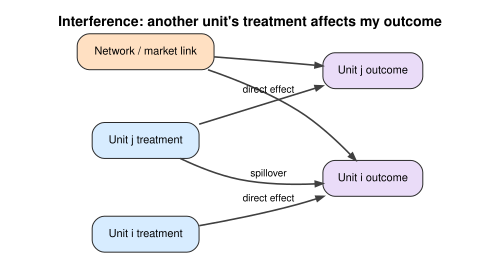

In [3]:
# Define the graph structure for the no-interference diagram.
interference_edges = [
    ("Unit i treatment", "Unit i outcome", "direct effect"),
    ("Unit j treatment", "Unit j outcome", "direct effect"),
    ("Unit j treatment", "Unit i outcome", "spillover"),
    ("Network / market link", "Unit i outcome"),
    ("Network / market link", "Unit j outcome"),
]
interference_colors = {
    "Unit i treatment": COLORS["assignment"],
    "Unit j treatment": COLORS["assignment"],
    "Unit i outcome": COLORS["outcome"],
    "Unit j outcome": COLORS["outcome"],
    "Network / market link": COLORS["network"],
}

smart_display(make_dag(interference_edges, "Interference: another unit's treatment affects my outcome", interference_colors))

The red flag is the arrow from unit $j$'s treatment to unit $i$'s outcome. Standard A/B testing logic usually assumes that arrow is absent. If it is present, the treatment contrast may still be useful, but we need to be precise about what it estimates.

## 2. Where Interference Appears in Industry

Interference is common in systems where units compete, collaborate, communicate, or share infrastructure.

| Setting | Unit | How interference happens |
|---|---|---|
| Marketplace ranking | Sellers, listings, drivers, restaurants | Treated units take attention, demand, or supply from controls |
| Social product | Users | Treated users create content or messages seen by untreated users |
| Collaboration software | Employees or teams | Treated employees change teammates' productivity |
| Ads and auctions | Advertisers, queries, campaigns | Budget, auction pressure, and ranking change outcomes for others |
| Geo or logistics | Cities, warehouses, delivery zones | Supply and demand move across boundaries |
| Fraud or trust systems | Accounts, devices, merchants | Bad actors adapt and move to untreated areas |
| Pricing and promotions | Buyers, sellers, regions | Treated prices change competition, inventory, and reference prices |

Sometimes interference is a nuisance because it contaminates a clean treatment comparison. Sometimes it is the main thing we care about: network growth, marketplace liquidity, peer learning, herd effects, social diffusion, congestion, and spillovers.

Tchetgen Tchetgen and VanderWeele (2010) define interference as a setting where one individual's exposure or treatment may affect other individuals' outcomes. Halloran and Struchiner (1995) emphasized this issue in infectious disease settings, where one person's treatment can directly affect another person's risk.

## 3. Direct, Spillover, and Total Effects

When interference is possible, we need more vocabulary.

| Effect | Informal question | Example |
|---|---|---|
| Direct effect | What happens to a treated unit, holding the treatment environment fixed? | Does the assistant help the employee who receives it? |
| Spillover effect | What happens to an untreated unit when nearby units are treated? | Do untreated teammates benefit from treated teammates? |
| Total effect | What happens if everyone is treated versus nobody treated? | What happens under full rollout? |
| Reallocation effect | Does treatment move value from one unit to another? | Does a seller boost shift demand from control sellers? |
| Equilibrium effect | Does the market settle into a different state after rollout? | Do prices, congestion, or supply adjust over time? |

The phrase "the treatment effect" is too vague in these settings. The right estimand depends on the decision.

## 4. Simulating a Networked Product Experiment

Suppose a company tests a collaboration assistant. A treated employee gets direct help from the assistant. Their collaborators may also benefit because treated employees produce clearer drafts, faster answers, or better documentation.

We will simulate a work network. Each employee has:

- Own treatment assignment.
- A fraction of treated neighbors.
- An outcome such as completed tasks or cycle-time improvement.
- A direct treatment effect.
- A spillover effect from treated neighbors.

**Dataset and experiment setup.** The network simulations represent users or sellers connected through markets, recommendations, social links, or shared demand. A unit's outcome can depend on its own treatment and on the treatment saturation around it. That makes the setup realistic for marketplaces and platforms, where one user's experience can change another user's exposure, competition, or congestion. The simulations define exposure mappings, market saturation, and spillover effects explicitly so the notebook can show why a standard individual A/B contrast may miss the full rollout effect.

In [4]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_network_experiment(
    n=650,
    degree=8,
    rewiring=0.08,
    saturation=0.50,
    direct_effect=1.2,
    spillover_effect=4.0,
    seed=20260428,
):
    """Generate a networked experiment with own-treatment and spillover effects.

    Args:
        n: Number of simulated units.
        degree: Average network degree or polynomial degree, depending on the helper context.
        rewiring: Network rewiring probability used in the small-world graph simulation.
        saturation: Share of units assigned in a network or market-level design.
        direct_effect: Own-treatment effect in the interference simulation.
        spillover_effect: Effect of neighbors or market saturation in the interference simulation.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    local_rng = np.random.default_rng(seed)
    graph = nx.watts_strogatz_graph(n=n, k=degree, p=rewiring, seed=seed)
    treatment = local_rng.binomial(1, saturation, n)
    exposure = neighbor_treated_share(graph, treatment)
    network_degree = np.array([graph.degree(i) for i in range(n)])
    engagement = local_rng.normal(0, 1, n)
    base = 45 + 2.5 * engagement + 0.18 * network_degree
    noise = local_rng.normal(0, 4.5, n)
    outcome = base + direct_effect * treatment + spillover_effect * exposure + noise
    all_control = base + noise
    all_treated = base + direct_effect + spillover_effect + noise
    df = pd.DataFrame({
        "employee_id": np.arange(n),
        "treated": treatment,
        "neighbor_treated_share": exposure,
        "degree": network_degree,
        "engagement": engagement,
        "outcome": outcome,
        "all_control_outcome": all_control,
        "all_treated_outcome": all_treated,
    })
    return df, graph


df_net, graph = simulate_network_experiment()
print(f"Employees: {len(df_net):,}")
print(f"Edges: {graph.number_of_edges():,}")
print(f"Treatment saturation: {df_net['treated'].mean():.3f}")
print(f"Average treated-neighbor share: {df_net['neighbor_treated_share'].mean():.3f}")
df_net.head()

Employees: 650
Edges: 2,600
Treatment saturation: 0.540
Average treated-neighbor share: 0.540


,employee_id,treated,neighbor_treated_share,degree,engagement,outcome,all_control_outcome,all_treated_outcome
0,0,1,0.571429,7,0.533690,49.036885,45.551171,50.751171
1,1,0,0.444444,9,-1.012513,54.541791,52.764014,57.964014
2,2,1,0.333333,9,0.553384,50.890891,48.357558,53.557558
3,3,0,0.500000,8,0.924518,53.462716,51.462716,56.662716
4,4,0,0.500000,8,-0.507471,57.570486,55.570486,60.770486


In Simulating a Networked Product Experiment, the table shows why exposure mapping matters. With connected units, a treated-control contrast can mix direct effects, spillovers, and design artifacts.

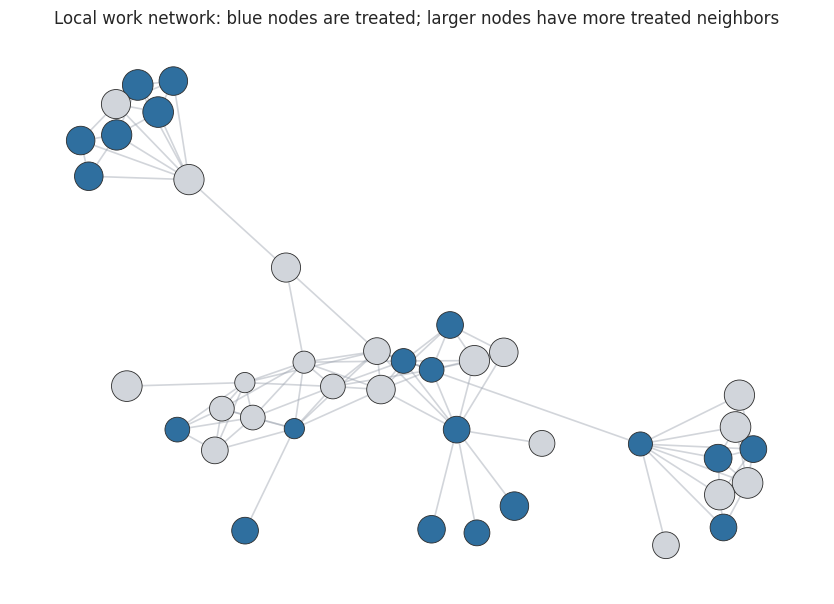

In [5]:
# Draw a readable local subgraph around one high-degree employee.
center = max(dict(graph.degree()).items(), key=lambda x: x[1])[0]
ego_nodes = list(nx.single_source_shortest_path_length(graph, center, cutoff=2).keys())
subgraph = graph.subgraph(ego_nodes).copy()
pos = nx.spring_layout(subgraph, seed=7)
node_colors = ["#2f6f9f" if df_net.loc[node, "treated"] == 1 else "#d1d5db" for node in subgraph.nodes()]
node_sizes = [160 + 420 * df_net.loc[node, "neighbor_treated_share"] for node in subgraph.nodes()]

fig, ax = plt.subplots(figsize=(8.5, 6.2))
nx.draw_networkx_edges(subgraph, pos, ax=ax, edge_color="#9ca3af", alpha=0.45, width=1.2)
nx.draw_networkx_nodes(subgraph, pos, ax=ax, node_color=node_colors, node_size=node_sizes, edgecolors="#2b2b2b", linewidths=0.6)
ax.set_title("Local work network: blue nodes are treated; larger nodes have more treated neighbors")
ax.axis("off")
plt.tight_layout()
plt.show()

In a networked experiment, a control unit can still be exposed to treatment through neighbors. A treated unit can have low or high exposure depending on how many neighbors are also treated. The observed condition is not just $Z_i$; it is some function of $Z_i$ and neighboring assignments.

## 5. The Individual A/B Contrast Is Not the Full Rollout Effect

An individual-level randomized experiment often compares treated employees with control employees. In this simulation, because assignment is independent, treated and control employees have similar average neighbor exposure. The contrast by own treatment mostly estimates the **direct effect**.

But a full rollout changes everyone from zero treated neighbors to all treated neighbors. That includes the spillover component. The full rollout effect can be much larger than the individual A/B contrast.

In [6]:
# Fit the statistical model and collect estimates used in the following interpretation.
naive_network = diff_in_means(df_net, "outcome", "treated")
exposure_model = smf.ols("outcome ~ treated + neighbor_treated_share", data=df_net).fit(cov_type="HC1")
full_rollout_effect = (df_net["all_treated_outcome"] - df_net["all_control_outcome"]).mean()

network_readout = pd.DataFrame([
    {"method": "Individual A/B contrast", **naive_network},
    {
        "method": "Regression coefficient: own treatment",
        "estimate": exposure_model.params["treated"],
        "se": exposure_model.bse["treated"],
        "ci_low": exposure_model.params["treated"] - 1.96 * exposure_model.bse["treated"],
        "ci_high": exposure_model.params["treated"] + 1.96 * exposure_model.bse["treated"],
        "p_value": exposure_model.pvalues["treated"],
    },
    {
        "method": "Regression coefficient: neighbor exposure",
        "estimate": exposure_model.params["neighbor_treated_share"],
        "se": exposure_model.bse["neighbor_treated_share"],
        "ci_low": exposure_model.params["neighbor_treated_share"] - 1.96 * exposure_model.bse["neighbor_treated_share"],
        "ci_high": exposure_model.params["neighbor_treated_share"] + 1.96 * exposure_model.bse["neighbor_treated_share"],
        "p_value": exposure_model.pvalues["neighbor_treated_share"],
    },
])

pd.DataFrame({
    "quantity": ["A/B contrast", "Estimated neighbor-exposure slope", "Full rollout effect", "True direct + spillover"],
    "value": [
        naive_network["estimate"],
        exposure_model.params["neighbor_treated_share"],
        full_rollout_effect,
        1.2 + 4.0,
    ],
}).round(3)

,quantity,value
0,A/B contrast,1.133
1,Estimated neighbor-exposure slope,5.337
2,Full rollout effect,5.200
3,True direct + spillover,5.200


In The Individual A/B Contrast Differs from the Full Rollout Effect, the output should be read as one estimand among several. Network spillovers can make an individual-level contrast miss the rollout effect.

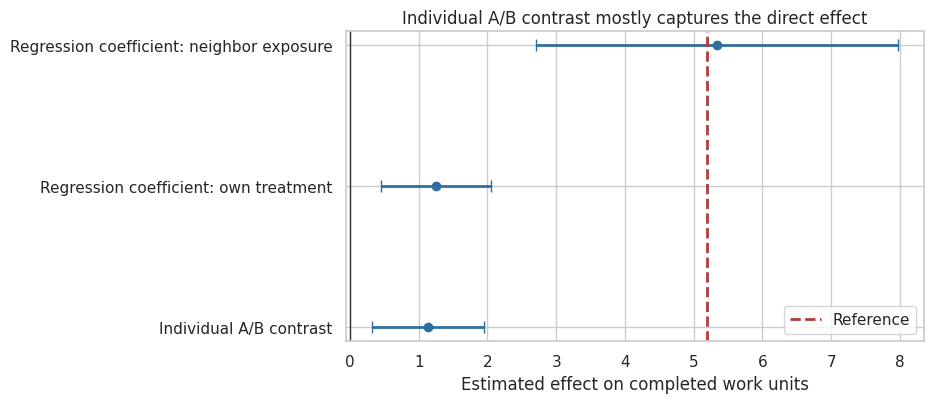

In [7]:
plot_ci_table(
    network_readout,
    title="Individual A/B contrast mostly captures the direct effect",
    xlabel="Estimated effect on completed work units",
    reference=full_rollout_effect,
    figsize=(9.5, 4.2),
)

The individual A/B contrast is much closer to the direct effect than to the full rollout effect. That is not a bug in randomization; it is a mismatch between estimand and decision.

If the decision is "Should this individual receive the assistant while the rest of the company remains at current saturation?" the direct contrast is useful. If the decision is "What happens if we roll this out to everyone?" the total effect includes spillovers.

## 6. Exposure Mappings

An **exposure mapping** compresses the full assignment vector $\mathbf{Z}$ into the part of the treatment environment believed to matter for unit $i$.

For example:

$$
E_i = \left(Z_i, \frac{1}{|N_i|}\sum_{j \in N_i} Z_j\right),
$$

where $N_i$ is the set of unit $i$'s neighbors. This says that a unit's outcome depends on own treatment and the fraction of treated neighbors, not on every detail of the full network assignment.

Aronow and Samii (2017) frame exposure mappings as a key component of randomization-based causal inference under interference. Ogburn and VanderWeele (2014) use causal diagrams to reason about mechanisms that can generate interference.

In [8]:
# Assemble the Exposure Mappings summary table used for interpretation.
df_exposure = df_net.copy()
df_exposure["neighbor_exposure_bucket"] = pd.cut(
    df_exposure["neighbor_treated_share"],
    bins=[-0.01, 0.25, 0.50, 0.75, 1.01],
    labels=["0-25%", "25-50%", "50-75%", "75-100%"],
)

exposure_summary = (
    df_exposure.groupby(["treated", "neighbor_exposure_bucket"], observed=False)
    .agg(
        n=("outcome", "size"),
        mean_outcome=("outcome", "mean"),
        mean_neighbor_share=("neighbor_treated_share", "mean"),
    )
    .reset_index()
)
exposure_summary.round(3)

,treated,neighbor_exposure_bucket,n,mean_outcome,mean_neighbor_share
0,0,0-25%,10,49.881,0.232
1,0,25-50%,134,48.098,0.431
2,0,50-75%,134,48.707,0.650
3,0,75-100%,21,50.231,0.857
4,1,0-25%,25,46.473,0.201
5,1,25-50%,143,49.353,0.426
6,1,50-75%,164,50.190,0.635
7,1,75-100%,19,52.580,0.831


In Exposure Mappings, read the table together with assignment quality, metric definitions, uncertainty, and guardrails. Randomization helps the estimate; practical meaning still decides the launch.

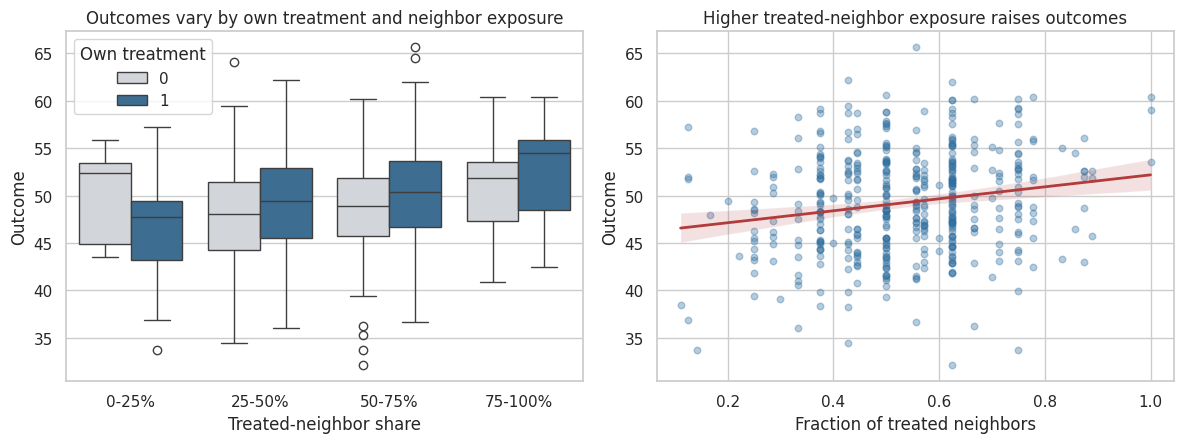

In [9]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

sns.boxplot(
    data=df_exposure,
    x="neighbor_exposure_bucket",
    y="outcome",
    hue="treated",
    palette={0: "#d1d5db", 1: "#2f6f9f"},
    ax=axes[0],
)
axes[0].set_title("Outcomes vary by own treatment and neighbor exposure")
axes[0].set_xlabel("Treated-neighbor share")
axes[0].set_ylabel("Outcome")
axes[0].legend(title="Own treatment")

sns.regplot(
    data=df_exposure.sample(450, random_state=12),
    x="neighbor_treated_share",
    y="outcome",
    scatter_kws={"alpha": 0.35, "s": 22, "color": "#2f6f9f"},
    line_kws={"color": "#b23b3b", "linewidth": 2},
    ax=axes[1],
)
axes[1].set_title("Higher treated-neighbor exposure raises outcomes")
axes[1].set_xlabel("Fraction of treated neighbors")
axes[1].set_ylabel("Outcome")
plt.tight_layout()
plt.show()

The exposure mapping turns a complex network assignment into a small set of interpretable exposure states. This is useful, but it is also an assumption. If the identity of treated neighbors matters, if central neighbors matter more, or if spillovers travel beyond one hop, then this mapping may be too simple.

A strong interference analysis should justify the exposure mapping with product knowledge, network structure, or a sensitivity analysis.

## 7. Treatment Saturation Changes the Meaning of the Contrast

Now vary the fraction of the network assigned to treatment. For each saturation level, we run a new randomized assignment and record:

- The overall mean outcome.
- The treated-control contrast, when both groups exist.

If spillovers are positive, the overall mean outcome rises with saturation. But the treated-control contrast remains closer to the direct effect because treated and control units in the same network share a similar treatment environment.

In [10]:
# Build the summary table used to connect the calculation back to the design question.
policy_rows = []
for saturation in [0.00, 0.10, 0.25, 0.50, 0.75, 0.90, 1.00]:
    for sim in range(120):
        df_sim, _ = simulate_network_experiment(saturation=saturation, seed=50_000 + int(saturation * 1000) * 1000 + sim)
        row = {
            "saturation": saturation,
            "mean_outcome": df_sim["outcome"].mean(),
            "observed_treatment_rate": df_sim["treated"].mean(),
        }
        if df_sim["treated"].nunique() == 2:
            row["ab_contrast"] = diff_in_means(df_sim, "outcome", "treated")["estimate"]
        else:
            row["ab_contrast"] = np.nan
        policy_rows.append(row)

policy_df = pd.DataFrame(policy_rows)
policy_summary = (
    policy_df.groupby("saturation", as_index=False)
    .agg(
        mean_outcome=("mean_outcome", "mean"),
        sd_outcome=("mean_outcome", "std"),
        mean_ab_contrast=("ab_contrast", "mean"),
        sd_ab_contrast=("ab_contrast", "std"),
    )
)
policy_summary.round(3)

,saturation,mean_outcome,sd_outcome,mean_ab_contrast,sd_ab_contrast
0,0.00,46.417,0.224,NaN,NaN
1,0.10,46.941,0.196,1.403,0.631
2,0.25,47.744,0.233,1.193,0.442
3,0.50,49.043,0.236,1.207,0.407
4,0.75,50.356,0.188,1.204,0.530
5,0.90,51.132,0.197,1.135,0.665
6,1.00,51.631,0.196,NaN,NaN


In Treatment Saturation Changes the Meaning of the Contrast, the table shows why exposure mapping matters. With connected units, a treated-control contrast can mix direct effects, spillovers, and design artifacts.

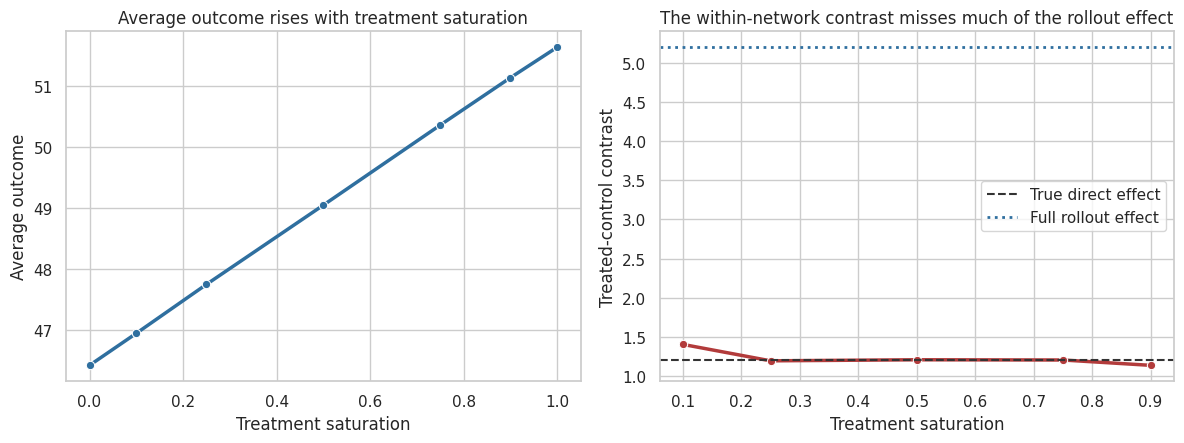

In [11]:
# Build the Treatment Saturation Changes the Meaning of the Contrast plot from the quantities computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

sns.lineplot(data=policy_summary, x="saturation", y="mean_outcome", marker="o", linewidth=2.5, color="#2f6f9f", ax=axes[0])
axes[0].set_title("Average outcome rises with treatment saturation")
axes[0].set_xlabel("Treatment saturation")
axes[0].set_ylabel("Average outcome")

contrast_plot = policy_summary.dropna(subset=["mean_ab_contrast"])
sns.lineplot(data=contrast_plot, x="saturation", y="mean_ab_contrast", marker="o", linewidth=2.5, color="#b23b3b", ax=axes[1])
axes[1].axhline(1.2, color="#333333", linestyle="--", linewidth=1.5, label="True direct effect")
axes[1].axhline(5.2, color="#2f6f9f", linestyle=":", linewidth=2, label="Full rollout effect")
axes[1].set_title("The within-network contrast misses much of the rollout effect")
axes[1].set_xlabel("Treatment saturation")
axes[1].set_ylabel("Treated-control contrast")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()

The left panel is a policy curve: what happens as the organization treats more people? The right panel is the individual treated-control contrast at each saturation. These are different objects.

A standard A/B test at 50% saturation can be internally valid for the direct contrast at 50% saturation and still be a poor estimate of the full rollout effect. This is why large platforms often care about holdouts, geo tests, cluster randomization, or saturation designs.

## 8. Reallocation Interference in Marketplaces

Some interference is not about positive social spillovers. It is about competition.

Suppose a marketplace gives treated sellers a ranking boost. Treated sellers may receive more demand, but some of that demand is taken from control sellers. The seller-level A/B effect can look positive even when total marketplace demand does not change.

This is one of the most important industry examples because it creates an appealing but misleading readout:

> "Treated sellers sold more, so the feature increased marketplace value."

Maybe. Or maybe the treatment just moved demand around.

In [12]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_seller_marketplace(n_markets=90, sellers_per_market=24, boost=0.75, design="seller", seed=20260430):
    """Generate a seller-marketplace example with reallocation interference.

    Args:
        n_markets: Number of markets generated in the simulation.
        sellers_per_market: Number of sellers generated inside each marketplace.
        boost: Treatment boost used in the seller-marketplace simulation.
        design: Experimental design label controlling how treatment is assigned.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    local_rng = np.random.default_rng(seed)
    rows = []
    for market_id in range(n_markets):
        market_demand = local_rng.lognormal(mean=8.0, sigma=0.35)
        seller_quality = local_rng.normal(0, 0.9, sellers_per_market)
        if design == "seller":
            treatment = local_rng.binomial(1, 0.5, sellers_per_market)
            market_treatment = np.nan
        elif design == "market":
            market_treatment = local_rng.binomial(1, 0.5)
            treatment = np.repeat(market_treatment, sellers_per_market)
        else:
            raise ValueError("design must be 'seller' or 'market'")

        ranking_score = np.exp(seller_quality + boost * treatment)
        expected_sales = market_demand * ranking_score / ranking_score.sum()
        sales = np.maximum(0, expected_sales + local_rng.normal(0, expected_sales.std() * 0.10, sellers_per_market))
        rows.append(pd.DataFrame({
            "market_id": market_id,
            "seller_id": np.arange(sellers_per_market),
            "seller_quality": seller_quality,
            "treated": treatment,
            "market_treatment": market_treatment,
            "sales": sales,
            "market_demand": market_demand,
            "design": design,
        }))
    return pd.concat(rows, ignore_index=True)


df_seller = simulate_seller_marketplace(design="seller")
df_market = simulate_seller_marketplace(design="market")

seller_level_effect = diff_in_means(df_seller, "sales", "treated")
market_totals = df_market.groupby(["market_id", "market_treatment"], as_index=False)["sales"].sum()
market_level_effect = diff_in_means(market_totals, "sales", "market_treatment")

marketplace_table = pd.DataFrame([
    {"method": "Seller-level randomization: treated seller sales", **seller_level_effect},
    {"method": "Market-level randomization: total market sales", **market_level_effect},
])
marketplace_table[["method", "estimate", "se", "ci_low", "ci_high"]].round(2)

,method,estimate,se,ci_low,ci_high
0,Seller-level randomization: treated seller sales,81.06,6.59,68.14,93.99
1,Market-level randomization: total market sales,-248.73,270.91,-779.71,282.25


In Reallocation Interference in Marketplaces, the table is a design check. Unexpected assignment or balance patterns are design problems first and metric problems second.

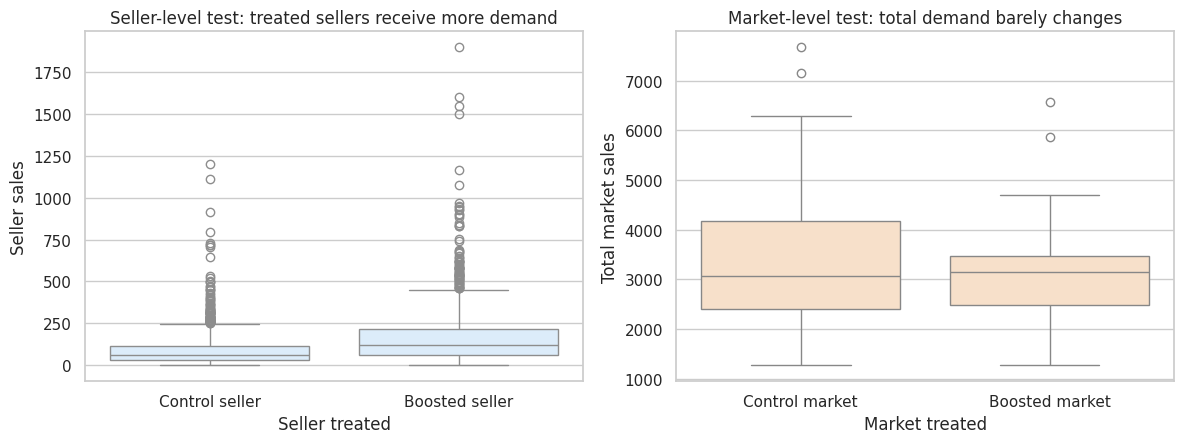

In [13]:
# Build the Reallocation Interference in Marketplaces plot from the quantities computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

sns.boxplot(data=df_seller, x="treated", y="sales", color="#d7ecff", ax=axes[0])
axes[0].set_title("Seller-level test: treated sellers receive more demand")
axes[0].set_xlabel("Seller treated")
axes[0].set_ylabel("Seller sales")
axes[0].set_xticklabels(["Control seller", "Boosted seller"])

sns.boxplot(data=market_totals, x="market_treatment", y="sales", color="#ffe0c2", ax=axes[1])
axes[1].set_title("Market-level test: total demand barely changes")
axes[1].set_xlabel("Market treated")
axes[1].set_ylabel("Total market sales")
axes[1].set_xticklabels(["Control market", "Boosted market"])
plt.tight_layout()
plt.show()

The seller-level test finds that boosted sellers sell more. That statement is true in the simulation. But the market-level test shows that total market sales barely move because the boost mostly reallocates demand across sellers.

This is why the randomization unit must match the decision. If the decision is whether to give one seller a ranking boost, seller-level randomization is relevant. If the decision is whether the platform should adopt a new ranking policy, a market-level or traffic-level design may be needed.

## 9. Partial Interference and Randomized Saturation Designs

One common compromise is **partial interference**: units are partitioned into groups, and interference is allowed within groups but not across groups. Examples include schools, villages, markets, sales territories, warehouses, or cities.

A **randomized saturation design** has two stages:

1. Randomize each group to a treatment saturation level, such as 0%, 25%, 50%, 75%, or 100%.
2. Within each group, randomize individuals according to that assigned saturation.

This design creates variation in both own treatment and the treatment environment. Hudgens and Halloran (2008) discuss two-stage randomization for interference settings, and Baird et al. (2018) formalize design choices for experiments in the presence of interference using randomized saturation designs.

In [14]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_saturation_design(n_markets=120, users_per_market=70, direct=1.4, spillover=4.5, seed=20260431):
    """Generate market-level saturation designs for spillover estimation.

    Args:
        n_markets: Number of markets generated in the simulation.
        users_per_market: Number of users generated inside each market.
        direct: Own-treatment effect in the saturation design.
        spillover: Saturation or peer-exposure effect in the design.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    local_rng = np.random.default_rng(seed)
    saturation_levels = np.array([0.00, 0.25, 0.50, 0.75, 1.00])
    market_saturation = np.resize(saturation_levels, n_markets)
    local_rng.shuffle(market_saturation)

    rows = []
    for market_id, saturation in enumerate(market_saturation):
        market_effect = local_rng.normal(0, 2.5)
        user_engagement = local_rng.normal(0, 1, users_per_market)
        n_treated = int(round(saturation * users_per_market))
        treatment = np.zeros(users_per_market, dtype=int)
        if n_treated > 0:
            treatment[local_rng.choice(users_per_market, size=n_treated, replace=False)] = 1
        outcome = (
            50
            + market_effect
            + 2.5 * user_engagement
            + direct * treatment
            + spillover * saturation
            + local_rng.normal(0, 5.0, users_per_market)
        )
        rows.append(pd.DataFrame({
            "market_id": market_id,
            "user_id": np.arange(users_per_market),
            "saturation": saturation,
            "treated": treatment,
            "outcome": outcome,
        }))
    return pd.concat(rows, ignore_index=True)


df_sat = simulate_saturation_design()
sat_summary = (
    df_sat.groupby(["saturation", "treated"], as_index=False)
    .agg(n=("outcome", "size"), mean_outcome=("outcome", "mean"))
)
sat_summary.round(3)

,saturation,treated,n,mean_outcome
0,0.00,0,1680,49.908
1,0.25,0,1248,50.586
2,0.25,1,432,51.889
3,0.50,0,840,52.115
4,0.50,1,840,53.755
5,0.75,0,432,53.459
6,0.75,1,1248,55.182
7,1.00,1,1680,56.337


In Partial Interference and Randomized Saturation Designs, the table shows why exposure mapping matters. With connected units, a treated-control contrast can mix direct effects, spillovers, and design artifacts.

In [15]:
# Assemble the Partial Interference and Randomized Saturation Designs summary table used for interpretation.
sat_model = smf.ols("outcome ~ treated + saturation", data=df_sat).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_sat["market_id"]},
)

sat_readout = pd.DataFrame({
    "method": ["Own treatment coefficient", "Market saturation coefficient"],
    "estimate": [sat_model.params["treated"], sat_model.params["saturation"]],
    "se": [sat_model.bse["treated"], sat_model.bse["saturation"]],
})
sat_readout["ci_low"] = sat_readout["estimate"] - 1.96 * sat_readout["se"]
sat_readout["ci_high"] = sat_readout["estimate"] + 1.96 * sat_readout["se"]
sat_readout.round(3)

,method,estimate,se,ci_low,ci_high
0,Own treatment coefficient,1.558,0.186,1.193,1.922
1,Market saturation coefficient,5.122,0.741,3.669,6.575


In Partial Interference and Randomized Saturation Designs, the output is tied to group-level variation. Precision should follow the saturation design, not the raw number of individual observations.

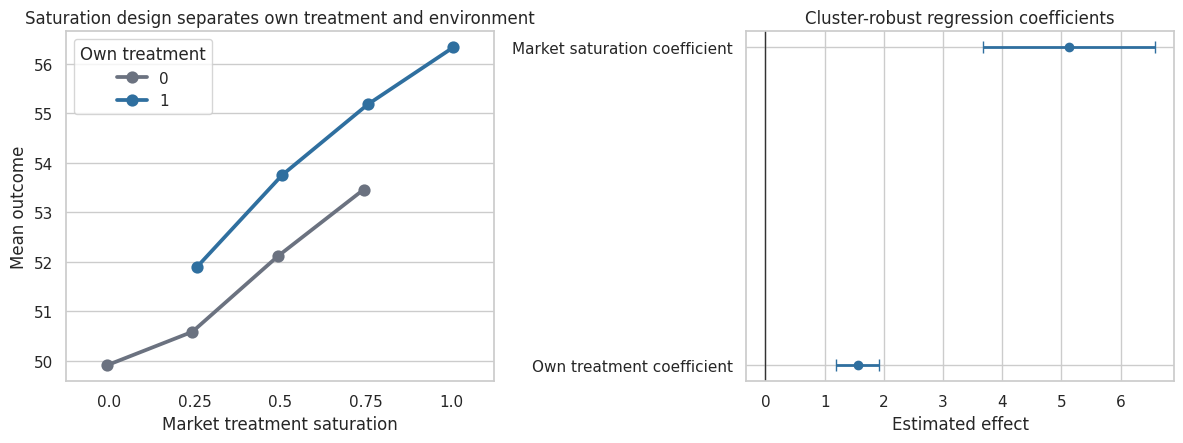

In [16]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

sns.pointplot(
    data=sat_summary,
    x="saturation",
    y="mean_outcome",
    hue="treated",
    dodge=True,
    palette={0: "#6b7280", 1: "#2f6f9f"},
    ax=axes[0],
)
axes[0].set_title("Saturation design separates own treatment and environment")
axes[0].set_xlabel("Market treatment saturation")
axes[0].set_ylabel("Mean outcome")
axes[0].legend(title="Own treatment")

ordered = sat_readout.sort_values("estimate")
y_pos = np.arange(len(ordered))
axes[1].errorbar(
    ordered["estimate"],
    y_pos,
    xerr=[ordered["estimate"] - ordered["ci_low"], ordered["ci_high"] - ordered["estimate"]],
    fmt="o",
    color="#2f6f9f",
    ecolor="#2f6f9f",
    elinewidth=2,
    capsize=4,
)
axes[1].axvline(0, color="#333333", linewidth=1)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(ordered["method"])
axes[1].set_title("Cluster-robust regression coefficients")
axes[1].set_xlabel("Estimated effect")
plt.tight_layout()
plt.show()

The own-treatment coefficient estimates a direct effect, while the saturation coefficient estimates how the group environment changes outcomes. A saturation design is powerful because it creates variation in both dimensions.

This design requires enough groups, careful operational control, and a clear definition of the group within which interference occurs. When spillovers are central to the decision, it is often far more informative than a simple individual-level A/B test.

## 10. Design Choices When Interference Is Plausible

| Design | Useful when | Main weakness |
|---|---|---|
| Individual randomization | Spillovers are weak or direct effect is the decision | Can miss total rollout effects |
| Cluster randomization | Interference mostly stays inside clusters | Needs many clusters; lower power |
| Geo or market randomization | Marketplace, pricing, logistics, ads, local supply-demand systems | Hard to balance regions; slow readout |
| Switchback design | Time-varying platform or operations intervention | Carryover and seasonality can interfere |
| Randomized saturation design | Need direct and spillover effects separately | More complex design and analysis |
| Network cluster randomization | Network links are known and spillovers follow links | Network may be incomplete or dynamic |
| Long-term holdout | Need equilibrium or long-run effects | Opportunity cost and contamination risk |

The right design depends on the interference mechanism. There is no universal fix.

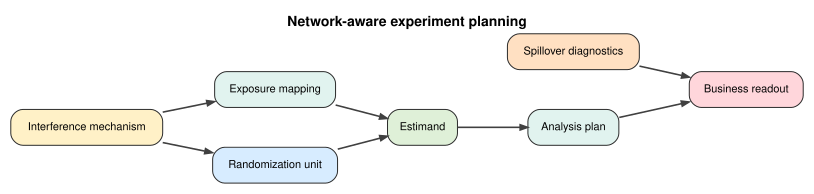

In [17]:
# Organize the calculation into readable steps for the lecture narrative.
design_edges = [
    ("Interference mechanism", "Randomization unit"),
    ("Interference mechanism", "Exposure mapping"),
    ("Randomization unit", "Estimand"),
    ("Exposure mapping", "Estimand"),
    ("Estimand", "Analysis plan"),
    ("Analysis plan", "Business readout"),
    ("Spillover diagnostics", "Business readout"),
]
design_colors = {
    "Interference mechanism": COLORS["warning"],
    "Randomization unit": COLORS["assignment"],
    "Exposure mapping": COLORS["analysis"],
    "Estimand": COLORS["spillover"],
    "Analysis plan": COLORS["analysis"],
    "Business readout": COLORS["decision"],
    "Spillover diagnostics": COLORS["network"],
}

smart_display(make_dag(design_edges, "Network-aware experiment planning", design_colors))

## 11. Interference Diagnostics and Planning Checklist

Before launching an experiment, ask:

| Question | Why it matters |
|---|---|
| Can treated units affect control units? | Detects possible SUTVA violations |
| Through what channel? | Competition, collaboration, congestion, learning, prices, supply, information |
| What is the business decision? | Direct effect and full rollout effect can differ |
| What is the right randomization unit? | User, account, team, market, region, query, time block |
| Are network or group links observed? | Determines whether exposure mappings are plausible |
| Is interference positive, negative, or reallocation? | Changes interpretation of A/B movement |
| Can we vary saturation? | Needed to separate direct and spillover effects |
| Are there enough independent groups? | Cluster or saturation designs need group-level power |
| Could behavior adapt over time? | Equilibrium effects may require longer holdouts |
| What will be reported? | ITT/direct/spillover/total effects should not be mixed |

A mature readout does not say only whether treatment won. It says what treatment environment was tested and what decision the estimate supports.

| field | example |
|---|---|
| Decision | Should we roll out the collaboration assistant to all enterprise teams? |
| Potential interference channel | Treated employees may improve teammates' outputs through shared documents and faster answers |
| Randomization unit | Team or saturation-randomized team, not isolated employee only |
| Observation unit | Employee-week |
| Exposure mapping | Own treatment plus fraction of treated teammates |
| Primary estimand | Total team-level effect under full rollout |
| Secondary estimands | Direct employee effect and spillover to untreated teammates |
| Design recommendation | Randomized saturation across teams if operationally feasible |
| Diagnostics | Compare outcomes by own treatment and teammate treatment saturation |
| Main caveat | Network links may be incomplete and spillovers may cross team boundaries |


## 12. Key Takeaways

- Interference means one unit's treatment can affect another unit's outcome.
- Under interference, potential outcomes depend on an assignment vector, not just own treatment.
- The standard individual A/B contrast may estimate a direct effect while missing spillovers or total rollout effects.
- Exposure mappings summarize the treatment environment, but they are assumptions that need domain justification.
- Positive network spillovers can make full rollout effects larger than individual A/B effects.
- Competitive marketplace spillovers can make seller-level effects look positive even when total platform value does not increase.
- Cluster, geo, network, switchback, and saturation designs are tools for aligning the experiment with the interference mechanism.
- Randomized saturation designs can separate direct effects from spillover effects when partial interference is plausible.
- The best readouts name the treatment environment tested, the estimand estimated, and the decision the result supports.

The next notebook will focus on experiment readouts for business teams: how to communicate causal evidence, uncertainty, guardrails, and decisions clearly.

## References

Aronow, P. M., & Samii, C. (2017). Estimating average causal effects under general interference, with application to a social network experiment. *The Annals of Applied Statistics, 11*(4). https://doi.org/10.1214/16-aoas1005

Baird, S., Bohren, J. A., McIntosh, C., & Özler, B. (2018). Optimal design of experiments in the presence of interference. *The Review of Economics and Statistics, 100*(5), 844-860. https://doi.org/10.1162/rest_a_00716

Halloran, M. E., & Struchiner, C. J. (1995). Causal inference in infectious diseases. *Epidemiology, 6*(2), 142-151. https://doi.org/10.1097/00001648-199503000-00010

Hudgens, M. G., & Halloran, M. E. (2008). Toward causal inference with interference. *Journal of the American Statistical Association, 103*(482), 832-842. https://doi.org/10.1198/016214508000000292

Manski, C. F. (2012). Identification of treatment response with social interactions. *The Econometrics Journal*. https://doi.org/10.1111/j.1368-423x.2011.00368.x

Ogburn, E. L., & VanderWeele, T. J. (2014). Causal diagrams for interference. *Statistical Science, 29*(4). https://doi.org/10.1214/14-sts501

Tchetgen Tchetgen, E. J., & VanderWeele, T. J. (2010). On causal inference in the presence of interference. *Statistical Methods in Medical Research, 21*(1), 55-75. https://doi.org/10.1177/0962280210386779